1. Préparation des données

1.1. Types des données

Importation des librairies

In [1]:
# update imported scripts (recommandation.py)
# stackoverflow 34758129
%load_ext autoreload
%autoreload 2

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from mlxtend.frequent_patterns import fpgrowth, apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

Lecture des données

In [2]:
df1 = pd.read_csv("cards_data.csv")
df2 = pd.read_csv("users_data.csv")
# Quantité importante de données de transactions, les fusions suivantes demandent trop de ressources, d'où la nécessité d'échantillonner
df3 = pd.read_csv("transactions_data.csv").loc[1600:11600] # pas ".sample(frac=0.10, random_state=42)" pour mieux refléter les séquences réelles
with open('train_fraud_labels.json', 'r') as df4:
    data1 = json.load(df4)
with open('mcc_codes.json', 'r') as df5:
    data2 = json.load(df5)

print()  # afin d'éviter de faire crash le notebook par l'affichage

Fusion de toutes les données

In [3]:
df2.rename(columns={"id": "client_id"}, inplace=True)

df_fusion = pd.merge(df1,df2, on="client_id", how="inner")
df_fusion.rename(columns={"id": "card_id"}, inplace=True)

df_fusion1 = pd.merge(df_fusion,df3, on=["client_id","card_id"], how="inner")
# Transformer le dictionnaire mcc en DataFrame
df_mcc = pd.DataFrame(list(data2.items()), columns=["mcc", "description"])
# Assurer que les types sont compatibles (int vs str)
df_fusion1["mcc"] = df_fusion1["mcc"].astype(int)
df_mcc["mcc"] = df_mcc["mcc"].astype(int)
# Fusionner sur la colonne 'code_mcc'
df_fusion2 = pd.merge(df_fusion1, df_mcc, on="mcc", how="left")

# Transformer le dictionnaire train_fraud_labels en DataFrame
# S'assurer que les types sont compatibles
df_fraud = pd.DataFrame(list(data1["target"].items()), columns=["id", "Statut"])
df_fusion2["id"] = df_fusion1["id"].astype(str)
df_fraud["id"] = df_fraud["id"].astype(str)
# Fusionner sur la colonne 'id'
df_fusion3 = pd.merge(df_fusion2, df_fraud, on="id", how="left")
df_fusion3.columns


Index(['card_id', 'client_id', 'card_brand', 'card_type', 'card_number',
       'expires', 'cvv', 'has_chip', 'num_cards_issued', 'credit_limit',
       'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web',
       'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender',
       'address', 'latitude', 'longitude', 'per_capita_income',
       'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'id',
       'date', 'amount', 'use_chip', 'merchant_id', 'merchant_city',
       'merchant_state', 'zip', 'mcc', 'errors', 'description', 'Statut'],
      dtype='object')

Exploration des 25000 premières lignes de donéées

In [ ]:
# Désactiver la troncature des lignes
df_fusion3.iloc[1:25000]


Suppression des colonnes non essentielles

In [ ]:
col_a_supprimer =['client_id', 'card_brand', 'expires', 'cvv', 'has_chip', 'num_cards_issued', 'use_chip', 'merchant_id', 'merchant_city', 'merchant_state', 'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web',
                  'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender', 'latitude', 'longitude', 'num_credit_cards', 'id', 'errors']
data = df_fusion3.drop(columns= col_a_supprimer).copy()
data

Détection des valeurs nulles

In [6]:
data.isna().sum()

card_id                 0
card_type               0
card_number             0
credit_limit            0
address                 0
per_capita_income       0
yearly_income           0
total_debt              0
credit_score            0
date                    0
amount                  0
zip                  1162
mcc                     0
description             0
Statut               3282
dtype: int64

Traitement et Évaluation des données manquantes

In [7]:
data.isnull().mean()*100

card_id               0.000000
card_type             0.000000
card_number           0.000000
credit_limit          0.000000
address               0.000000
per_capita_income     0.000000
yearly_income         0.000000
total_debt            0.000000
credit_score          0.000000
date                  0.000000
amount                0.000000
zip                  11.618838
mcc                   0.000000
description           0.000000
Statut               32.816718
dtype: float64

Nettoyage des données

In [ ]:
df = data[data['Statut'].notnull()].copy()
zip_score = df['zip'].mean()
df.fillna({'zip':zip_score}, inplace=True)
df

In [9]:
df.isna().sum()

card_id              0
card_type            0
card_number          0
credit_limit         0
address              0
per_capita_income    0
yearly_income        0
total_debt           0
credit_score         0
date                 0
amount               0
zip                  0
mcc                  0
description          0
Statut               0
dtype: int64

Création et Ajout des varaibles dérivées

In [10]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['jour'] = df['date'].dt.day_name()
df['heure'] = df['date'].dt.hour

#Intervalle entre deux transactions
df.sort_values(['card_id', 'date'], inplace=True)
df['delta'] = df.groupby('card_id')['date'].diff()

#Variable pour la période
def assign_periode(h):
    if 5 <= h < 12:
        return 'matin'
    elif 12 <= h < 17:
        return 'après-midi'
    elif 17 <= h < 21:
        return 'soir'
    else:
        return 'nuit'
df['periode'] = df['heure'].apply(assign_periode)

#Ratio dette/revenu : 
for col in ['total_debt', 'yearly_income']:
    df[col] = df[col].str.replace('$', '', regex=False).str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
df['debt_income_ratio'] = pd.to_numeric(df['total_debt'], errors='coerce') / pd.to_numeric(df['yearly_income'], errors='coerce')

# Nettoyage du symbole dollar et des espaces
df['amount'] = df['amount'].str.replace('$', '', regex=False).str.strip()

# Conversion en numérique
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

#Montant normalisé
df['Montant_Normalisé'] = (df['amount'] - df['amount'].mean()) / df['amount'].std()

#Catégorie de montant
q1 = df['amount'].quantile(0.25)
q2 = df['amount'].quantile(0.50)
q3 = df['amount'].quantile(0.75)
def categorize_amount(x):
    if x <= q1: return 'low'
    elif x <= q2: return 'medium'
    elif x <= q3: return 'high'
    else: return 'very_high'
df['amount_category'] = df['amount'].apply(categorize_amount)

#Type de carte encodé : 
df['card_type_item'] = df['card_type'].apply(lambda x: f'card_{x.lower()}')

#Score de crédit catégorisé
df['credit_score_item'] = df['credit_score'].apply(
    lambda x: 'credit_high' if x >= 700 else ('credit_medium' if x >= 500 else 'credit_low')
)

#Fréquence d’utilisation de la carte
df['card_usage_freq'] = df.groupby('card_id')['card_id'].transform('count')

#Variable cible (Statut) si frauduleux ou pas
df['is_fraud'] = df['Statut'].apply(lambda x: 1 if x == 'Yes' else 0)

#Catégorie MCC enrichie : si tu as un fichier de correspondance MCC
df['mcc_category'] = df['description']


#Type de commerce encodé : 
df['merchant_type'] = df['description'].str.lower().str.replace(' ', '_')

df.isna().sum()

card_id                 0
card_type               0
card_number             0
credit_limit            0
address                 0
per_capita_income       0
yearly_income           0
total_debt              0
credit_score            0
date                    0
amount                  0
zip                     0
mcc                     0
description             0
Statut                  0
jour                    0
heure                   0
delta                2043
periode                 0
debt_income_ratio       0
Montant_Normalisé       0
amount_category         0
card_type_item          0
credit_score_item       0
card_usage_freq         0
is_fraud                0
mcc_category            0
merchant_type           0
dtype: int64

Diagramme en secteurs du nombre de transactions des top 10 commerçants

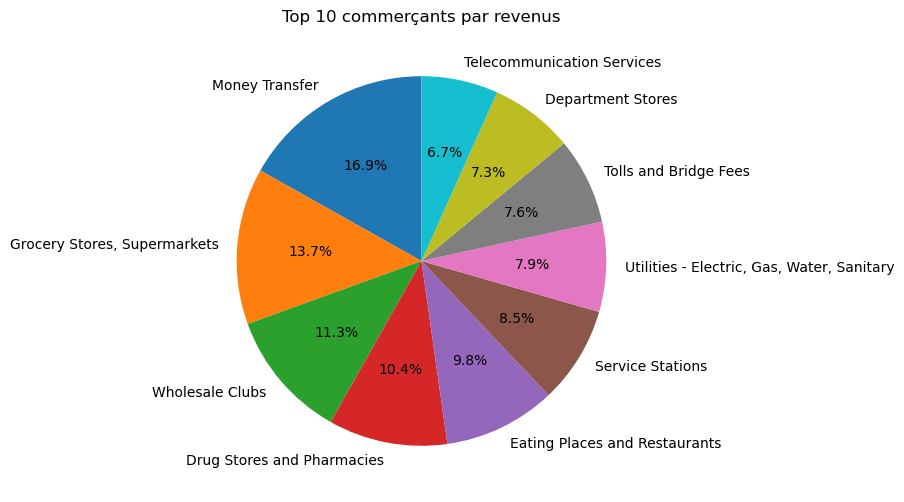

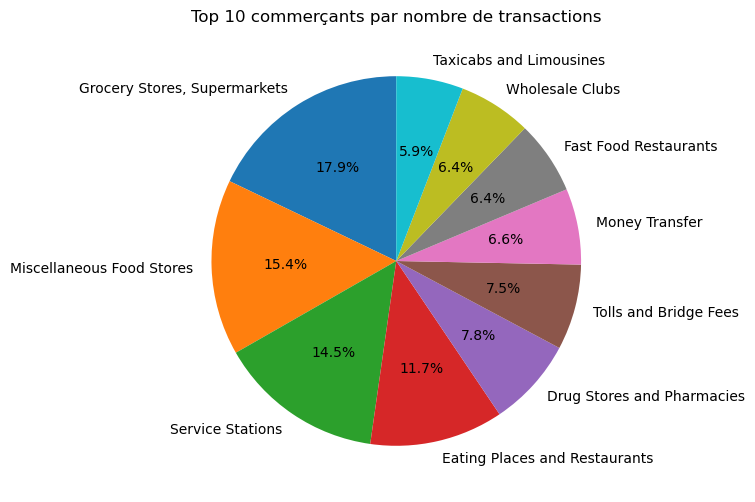

In [11]:
# Assure-toi que 'amount' est bien numérique
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

# Top 10 commerçants par revenus
top_revenue = df.groupby('description')['amount'].sum().sort_values(ascending=False).head(10)

# Top 10 commerçants par nombre de transactions
top_count = df['description'].value_counts().head(10)

# Diagramme en secteurs – revenus
plt.figure(figsize=(8, 6))
top_revenue.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Top 10 commerçants par revenus')
plt.ylabel('')
plt.show()

# Diagramme en secteurs – nombre de transactions
plt.figure(figsize=(8, 6))
top_count.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Top 10 commerçants par nombre de transactions')
plt.ylabel('')
plt.show()

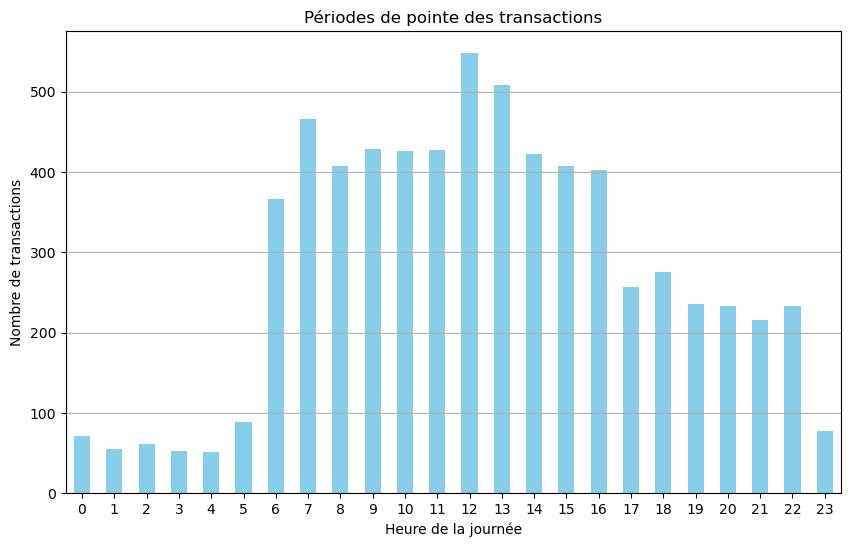

In [12]:
# Histogramme des heures
plt.figure(figsize=(10, 6))
df['heure'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Périodes de pointe des transactions')
plt.xlabel('Heure de la journée')
plt.ylabel('Nombre de transactions')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


# **2. Analyse d'associations**

#### 2.1 *Transformation des données en données transactionnelles*


In [ ]:

# Colonnes pour les transactions
cols_to_use =  ['card_type', 'credit_score_item', 'mcc_category', 'merchant_type', 'amount_category', 'Statut', 'periode']

# Gestion des valeurs manquantes
for col in cols_to_use:
    df[col] = df[col].astype(str).fillna('Unknown')

# Création des données transactionnelles (transactions)
def make_transactions(x):
    items = []
    for col in cols_to_use:
        items += x[col].tolist()
    items += x['Statut'].tolist()
    return items 

# Créer les transactions selon l'id de la carte
df_sample = df#.sample(5000) 
transactions = df_sample.groupby('card_id').apply(make_transactions).tolist()

C:\Users\lucna\AppData\Local\Temp\ipykernel_26600\3212354688.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  transactions = df_sample.groupby('card_id').apply(make_transactions).tolist()


In [ ]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

transactions_df = pd.DataFrame(te_array, columns=te.columns_)
transactions_df

#### 2.2 *Génération de règles d'association par Apriori et FP-Growth*

In [15]:
# Génération des itemsets fréquents avec Apriori
frequent_itemsets_apriori = apriori(transactions_df, min_support=0.02, use_colnames=True)

# Génération des règles d'association
rules_apriori = association_rules(frequent_itemsets_apriori, metric="lift", min_threshold=1.2)

# Génération des itemsets fréquents avec FP-Growth
frequent_itemsets_fpgrowth = fpgrowth(transactions_df, min_support=0.02, use_colnames=True)

# Génération des règles d'association
rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric="lift", min_threshold=1.2)

# Conversion de frozenset à string pour une meilleure lisibilité
rules_apriori['antecedents'] = rules_apriori['antecedents'].apply(lambda x: ', '.join(list(x)) if x else '')
rules_apriori['consequents'] = rules_apriori['consequents'].apply(lambda x: ', '.join(list(x)) if x else '')

rules_fpgrowth['antecedents'] = rules_fpgrowth['antecedents'].apply(lambda x: ', '.join(list(x)) if x else '')
rules_fpgrowth['consequents'] = rules_fpgrowth['consequents'].apply(lambda x: ', '.join(list(x)) if x else '')

#### 2.3, 2.4 et 2.5 *Affichage des règles transactionnelles selon les questions*

In [16]:
# Question 2.3 : MCC et dépenses élevées
import re

mcc_types = df['mcc_category'].unique()
amount_type = df['amount_category'].unique()

mcc_regex = '|'.join([re.escape(x) for x in mcc_types])
amount_regex = 'high|very_high'

rules_mcc_expenses_ap = rules_apriori[
    (
        rules_apriori['antecedents'].str.contains(mcc_regex, case=False) &
        rules_apriori['consequents'].str.contains(amount_regex, case=False)
    )
    |
    (
        rules_apriori['antecedents'].str.contains(amount_regex, case=False) & 
        rules_apriori['consequents'].str.contains(mcc_regex, case=False)
    )
]

print("Règles d'association (MCC et dépenses élevées) - Apriori:")
for idx, row in rules_mcc_expenses_ap.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

rules_mcc_expenses_fp = rules_fpgrowth[
    (
        rules_fpgrowth['antecedents'].str.contains(mcc_regex, case=False) &
        rules_fpgrowth['consequents'].str.contains(amount_regex, case=False)
    )
    |
    (
        rules_fpgrowth['antecedents'].str.contains(amount_regex, case=False) & 
        rules_fpgrowth['consequents'].str.contains(mcc_regex, case=False)
    )
]

print("\nRègles d'association (MCC et dépenses élevées) - FP-Growth:")
for idx, row in rules_mcc_expenses_fp.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

Règles d'association (MCC et dépenses élevées) - Apriori:
Automotive Service Shops -> high (support: 0.079, lift: 1.64)
high -> Automotive Service Shops (support: 0.079, lift: 1.64)
Automotive Service Shops -> very_high (support: 0.058, lift: 1.25)
very_high -> Automotive Service Shops (support: 0.058, lift: 1.25)
Department Stores -> high (support: 0.061, lift: 1.26)

Règles d'association (MCC et dépenses élevées) - FP-Growth:
high -> Eating Places and Restaurants (support: 0.139, lift: 1.27)
Eating Places and Restaurants -> high (support: 0.139, lift: 1.27)
high, No -> Eating Places and Restaurants (support: 0.139, lift: 1.27)
No, Eating Places and Restaurants -> high (support: 0.139, lift: 1.27)
high -> No, Eating Places and Restaurants (support: 0.139, lift: 1.27)


Par la sortie qui suit, on voit que dans notre DataFrame prétraité, il y a des associations entre le type de commerce et les hautes dépenses. Le commerce le plus concerné est *Automotive Service Shops* où les dépenses varient de hautes à très hautes. Les patterns comportementaux qui ressortent sont que les gens dépensent de grandes sommes dans les magasins de réparation automobile.

In [17]:
# Question 2.4 : Types de cartes et types de commerçants
import re

card_types = df['card_type'].unique()
merchant_types = df['merchant_type'].unique()

# Créer une regex qui matche n'importe quelle valeur
card_regex = '|'.join([re.escape(str(x)) for x in card_types])
merchant_regex = '|'.join([re.escape(str(x)) for x in merchant_types])

rules_card_merchant_ap = rules_apriori[
    (
        rules_apriori['antecedents'].str.contains(card_regex, case=False) & 
        rules_apriori['consequents'].str.contains(merchant_regex, case=False)
    )
    |
    (
        rules_apriori['antecedents'].str.contains(merchant_regex, case=False) & 
        rules_apriori['consequents'].str.contains(card_regex, case=False)
    )
]

print("Règles d'association (Types de cartes et types de commerçants) - Apriori:")
for idx, row in rules_card_merchant_ap.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

rules_card_merchant_fp = rules_fpgrowth[
    (
        rules_fpgrowth['antecedents'].str.contains(card_regex, case=False) &
        rules_fpgrowth['consequents'].str.contains(merchant_regex, case=False)
    )
    |
    (
        rules_fpgrowth['antecedents'].str.contains(merchant_regex, case=False) & 
        rules_fpgrowth['consequents'].str.contains(card_regex, case=False)
    )   
]

print("\nRègles d'association (Types de cartes et types de commerçants) - FP-Growth:")
for idx, row in rules_card_merchant_fp.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

Règles d'association (Types de cartes et types de commerçants) - Apriori:
Credit -> utilities_-_electric,_gas,_water,_sanitary (support: 0.021, lift: 1.23)
utilities_-_electric,_gas,_water,_sanitary -> Credit (support: 0.021, lift: 1.23)
book_stores -> Debit (support: 0.034, lift: 1.21)
Debit -> book_stores (support: 0.034, lift: 1.21)
discount_stores -> credit_medium (support: 0.027, lift: 1.49)

Règles d'association (Types de cartes et types de commerçants) - FP-Growth:
Debit, Eating Places and Restaurants -> grocery_stores,_supermarkets (support: 0.053, lift: 1.21)
grocery_stores,_supermarkets -> Debit, Eating Places and Restaurants (support: 0.053, lift: 1.21)
credit_medium, Eating Places and Restaurants -> grocery_stores,_supermarkets (support: 0.032, lift: 1.21)
grocery_stores,_supermarkets -> credit_medium, Eating Places and Restaurants (support: 0.032, lift: 1.21)
Debit, No, Eating Places and Restaurants -> grocery_stores,_supermarkets (support: 0.053, lift: 1.21)


Ici, la seule association pertinente est entre les magasins à rabais et la côte de crédit *credit_medium*. Cela nous révèle que les utilisateurs ont une côte de crédit moyenne (pas haute, ni basse) lorsqu'ils dépensent dans des magains à rabais.

In [18]:
# Question 2.5 : Fraude et autres variables

rules_fraud_ap = rules_apriori[
    ( 
        rules_apriori['consequents'].str.contains('Yes', case=False)
    )
]

print("Règles d'association (Fraude et autres variables) - Apriori:")
for idx, row in rules_fraud_ap.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

rules_fraud_fp = rules_fpgrowth[
    ( 
        rules_fpgrowth['consequents'].str.contains('Yes', case=False)
    )
]

print("\nRègles d'association (Fraude et autres variables) - FP-Growth:")
for idx, row in rules_fraud_fp.head().iterrows():
    print(f"{row['antecedents']} -> {row['consequents']} (support: {row['support']:.3f}, lift: {row['lift']:.2f})")

Règles d'association (Fraude et autres variables) - Apriori:

Règles d'association (Fraude et autres variables) - FP-Growth:


On peut voir qu'on ne trouve aucune corrélation entre les autres variables et la fraude, surtout parce que toutes les règles ne pointent pas vers de la fraude. On peut voir cela par le fait que le lift est supérieur au minimum posé, soit 1.2, signifiant une corrélation positive, surtout les deux premières règles crées par *Apriori*. 

#### 2.6 *Explication et visualisation des métriques associés aux règles*

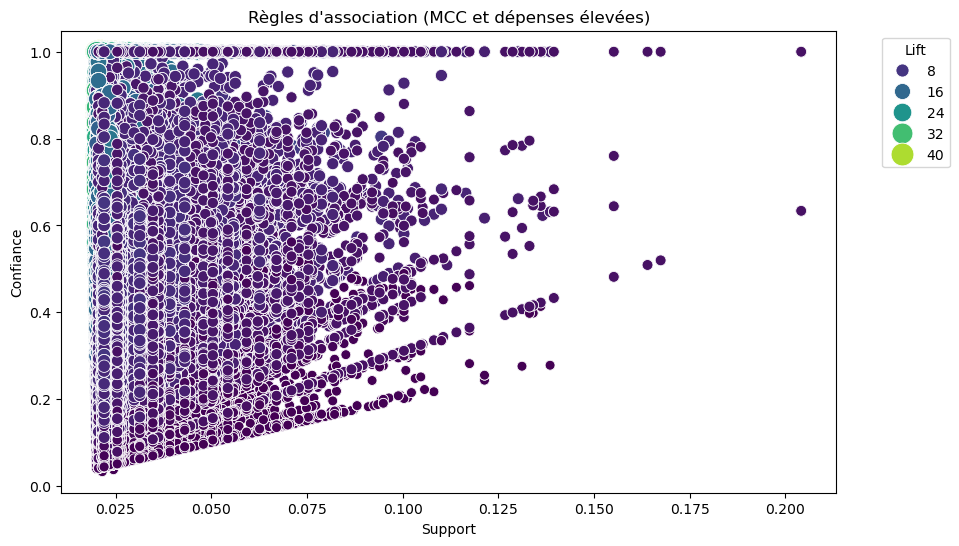

In [19]:
rules_mcc_expenses_copy = rules_mcc_expenses_ap.copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='support',
    y='confidence',
    size='lift',
    hue='lift',
    data=rules_mcc_expenses_copy,
    palette='viridis',
    sizes=(50, 300)
)

plt.title('Règles d\'association (MCC et dépenses élevées)')
plt.xlabel('Support')
plt.ylabel('Confiance')
plt.legend(title='Lift', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Le support correspond au pourcentage de *"popularité"* dans le sens que sur ~2000 transactions, le pourcentage montré est le nombre de transactions où la règle apparaît le plus souvent. La confiance correspond au pourcentage de *"fiabilité*, soit que par rapport au support, un pourcentage de transactions suit une règle contenant plusieurs arguments à gauche comme un haut crédit, des dépenses basses et la librairie. Le lift correspond à la pertinence de la règle et si la limite posée est dépassée, cela signifie que ce n'est pas par hasard que les arguments de la règle sont associés entre eux (corrélation positive). Si on a un lift égal à la limite, les arguments de la règle sont indépendants (aucune corrélation). Si on a un lift inférieur à la limite, les arguments de la règle n'ont aucun lien entre eux (corrélation négative).

#### 2.7 *Choix du seuil du support minimal*

Pour le seuil de support minimal, on a choisi d'aller avec 0.02, afin de prendre en compte, à la fois les cas spécifiques et les cas généraux, sans avoir trop de bruit dans les données et sans manquer de cas spécifiques. Puisque qu'on est à un peu moins de 10 000 transactions, cette valeur est très justifié. 

(On a pris un échantillon de 10 000 pour des fins de tests. Lancer des millions de transactions dans des algorithmes comme *Apriori* et *FP-Growth* ne ferait que ralentir le processus en plus de causer énormément de bruit dans les résultats)

# **3. Analyse de séquence**

#### 3.1 *Construction des séquences clients*

Comment construire des séquences de transactions par clients ? 
À partir de quelle variable les ordonner ?

Pour construire des séquences client, une solution est d'ordonnancer les transactions par horodatage avec l'attribut `date` qui traduira une évolution dans le temps. Chaque séquence serait constituée d'itemsets formés d'attributs catégoriels tels que `amount_category` qui permettent de comparer les comportements plus facilement. Dans ce cas d'étude, l'itemset modèle sera composé de:
- `merchant_type`
- `amount_category`
- `periode`
- `Statut`

Par la suite, on se rend compte qu'un itemset avec autant de conditions peut être trop restrictif (support minimale de 1% peu représentatif pour obtenir 3 séquences typiques seulement). Il peut alors être intéressant de se focaliser sur `merchant_type` et d'augmenter la taille de l'échantillon.

In [21]:
features = ['merchant_type', 'amount_category', 'periode', 'Statut']
df_seq = df[['card_id','date'] + features].sort_values(['card_id','date']).reset_index(drop='true')

# Pour chaque client, on veut l'ensemble des données ordonnées par horodatage 
sequences = (
    df_seq
    .groupby('card_id')[features[0]]
    .apply(list) # éléments en liste
    .tolist() # de DataFrame à liste
)

print("Nombre de clients et de leurs séquences de transactions: ", len(sequences))
pd.set_option("display.max_colwidth", 100)

Nombre de clients et de leurs séquences de transactions:  2043


Validation...

In [22]:
for i, seq in enumerate(sequences[:3]):
    print(f"Séquence {i+1} (longueur={len(seq)}):")
    for step in seq[:5]: 
        print("  ", step)
    if len(seq) > 5:
        print("  ...")
    print()

Séquence 1 (longueur=2):
   drinking_places_(alcoholic_beverages)
   eating_places_and_restaurants

Séquence 2 (longueur=2):
   money_transfer
   telecommunication_services

Séquence 3 (longueur=10):
   tools,_parts,_supplies_manufacturing
   money_transfer
   miscellaneous_food_stores
   miscellaneous_home_furnishing_stores
   miscellaneous_food_stores
  ...



#### 3.2 *Parcours typiques avec l'algorithme PrefixSpan*

Identifier les parcours clients typiques par projection récursive de préfixes séquentiels.

In [23]:
from prefixspan import PrefixSpan

ps = PrefixSpan(sequences)
ps.minlen, ps.maxlen = 2, 5
# une séquence de 1 item ne fait pas sens,
# pour 10 000 transactions avec environ 2000 clients, 
# on a moins de 5 événements par client en moyenne


support_min = 0.02 # support significatif
motifs = ps.frequent(int(support_min*len(sequences)))

#### 3.3 *Parcours d'achat et routine fréquentes*


Sur 10 000 transactions enregistrées dans le jeu de données, 35 séquences typiques sont extraites avec une support relatif de 2% sur les ~2000 séquences clientes. Avec cette quantité raisonnable, un tri descendant suffit. Elles concernent toutes des MCC liés à l'alimentaire ou la mobilité et la plus fréquente est `[miscellaneous_food_stores, miscellaneous_food_stores]` avec un support absolu de 191. Plus généralement, on remarque qu'une grande partie de séquences sont des répétitions d'un même type de marchand. 

In [24]:
motif_df = (
    pd.DataFrame(motifs, columns=['support', 'motif'])
    .sort_values(['support'], ascending=[False])
    .reset_index(drop=True)
)

motif_df

,support,motif
0,191,"[miscellaneous_food_stores, miscellaneous_food_stores]"
1,147,"[service_stations, service_stations]"
2,142,"[grocery_stores,_supermarkets, grocery_stores,_supermarkets]"
3,101,"[eating_places_and_restaurants, grocery_stores,_supermarkets]"
4,91,"[grocery_stores,_supermarkets, eating_places_and_restaurants]"
5,87,"[miscellaneous_food_stores, miscellaneous_food_stores, miscellaneous_food_stores]"
6,86,"[grocery_stores,_supermarkets, service_stations]"
7,85,"[tolls_and_bridge_fees, tolls_and_bridge_fees]"
8,81,"[eating_places_and_restaurants, eating_places_and_restaurants]"
9,80,"[grocery_stores,_supermarkets, drug_stores_and_pharmacies]"


#### 3.4 *Motifs précédant une transaction frauduleuse*

Dans le cadre d'une nouvelle analyse sur la fraude, les séquences seront redéfinies pour inclure le marqueur de fraude et un autre item pour former un itemset `Tuple` qui sera traité pour extraire des motifs précédant une transaction frauduleuse.

In [25]:
# # Aucune fraud ? Fraude artificielle de test
# df_seq.loc[11, 'Statut'] = 'Yes'

df_fraud = (df_seq
           .groupby('card_id', group_keys=False)
           .filter(lambda g: (g['Statut'] == 'Yes').any()))

print("Client Frauduleux:\n\n", df_fraud[['card_id','Statut']], "\n\n\n")

fraud_sequences = (
    df_fraud
    .groupby('card_id')[['merchant_type', 'Statut']]
    .apply(lambda g: list(g.itertuples(index=False, name=None)))
    .tolist()
)

print("Séquences clientes contenant une fraude au moins: \n\n", fraud_sequences, "\n\n\n") 


ps = PrefixSpan(fraud_sequences)
ps.minlen, ps.maxlen = 2, 5

support_min = 0.02 # support significatif
motifs = ps.frequent(int(support_min*len(sequences)))

fraud_motif_df = (
    pd.DataFrame(motifs, columns=['support', 'motif'])
    .sort_values(['support'], ascending=[False])
    .reset_index(drop=True)
)


print("Séquences frauduleuses:\n\n", fraud_motif_df, "\n\n\n")


Client Frauduleux:

       card_id Statut
5973     5497    Yes
5974     5497     No
5975     5497     No
5976     5497    Yes
5977     5497     No 



Séquences clientes contenant une fraude au moins: 

 [[('travel_agencies', 'Yes'), ('wholesale_clubs', 'No'), ('motion_picture_theaters', 'No'), ('lighting,_fixtures,_electrical_supplies', 'Yes'), ('wholesale_clubs', 'No')]] 



Séquences frauduleuses:

 Empty DataFrame
Columns: [support, motif]
Index: [] 





#### 3.5 *Évolutions du comportement*

Dans le cadre d'une étude sur les évolutions de comportements, un échantillon plus conséquent aurait permis une segmentation dans le temps pour faire des comparatifs de séquences fréquentes.

#### 3.6 *Visualisations des comportements transactionnels*

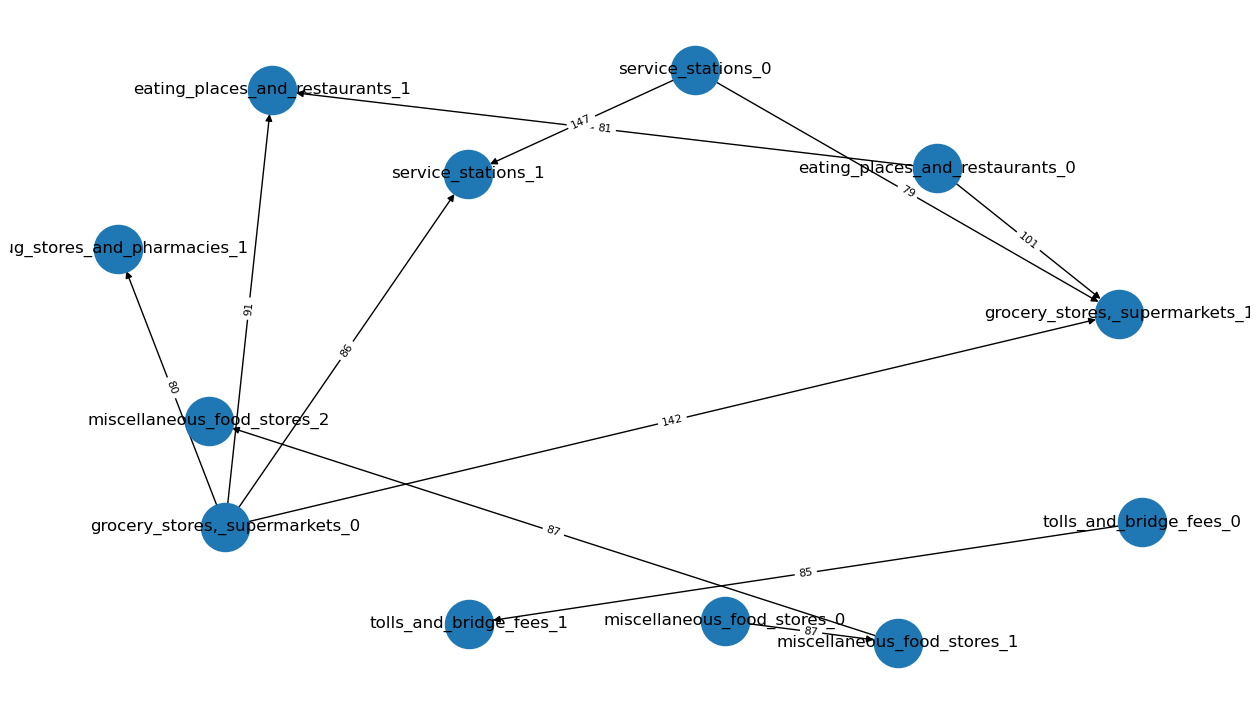

In [26]:
import networkx
G = networkx.DiGraph()

graph_df = (
    motif_df
    .loc[1:10]
    .sort_values(['support'], ascending=[True])
    .itertuples(index=False, name=None)
)

for support, motif in graph_df:
    for i in range(len(motif)-1):
        # the following has a better representation 
        # with self-loops, but they overlap 
        # G.add_edge(motif[i], motif[i+1], weight=support)
        # thus...
        G.add_edge(motif[i]+f"_{i}", motif[i+1]+f"_{i+1}", weight=support)

pos = networkx.spring_layout(G, seed=42, k=6, iterations=20)

plt.figure(figsize=(16,9))
networkx.draw_networkx(G, pos, with_labels=True, node_size=1200, arrows=True)
networkx.draw_networkx_edge_labels(G, pos, edge_labels=networkx.get_edge_attributes(G, 'weight'), font_size=8)
plt.axis('off');  plt.show()

# **4. Système de Recommandation**

Basé sur PrefixSpan, le système de recommandation reprend les logiques exposées précédemment et utilise un dictionnaire pour associer aux séquences partielles leur complémentaire directement extrait des données. On a ainsi le prochain item le plus probable avec le support absolu de la séquence pour justifier la recommandation.

Par défaut, l'item recommandé est l'item le plus fréquent. Par exemple, ici `grocery_stores,_supermarkets` sera l'item le plus probable avec 834 occurences dans le jeu de données.

In [27]:
from recommandation import recommend

print("Par défaut:\n",
    recommend(data=df, group='card_id', order='date', item='merchant_type', seq=['random']))

print("\nSéquence simple:\n",
    recommend(data=df, group='card_id', order='date', item='merchant_type', seq=['miscellaneous_food_stores']))

print("\nDeux items:\n",
    recommend(data=df, group='card_id', order='date', item='merchant_type', seq=['miscellaneous_food_stores', 'miscellaneous_food_stores']))

Par défaut:
 (['grocery_stores,_supermarkets'], 834)

Séquence simple:
 (['miscellaneous_food_stores'], 191)

Deux items:
 (['miscellaneous_food_stores'], 87)


# **5. Analyse statistique comparative des classes**

#### *5.1 Distribution et réduction de dimension*

c:\Users\lucna\.conda\envs\IFT599_TP1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


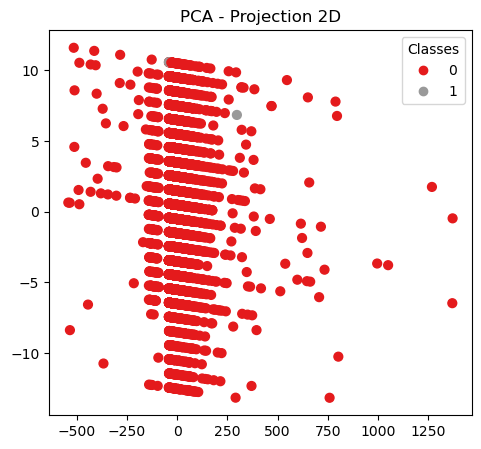

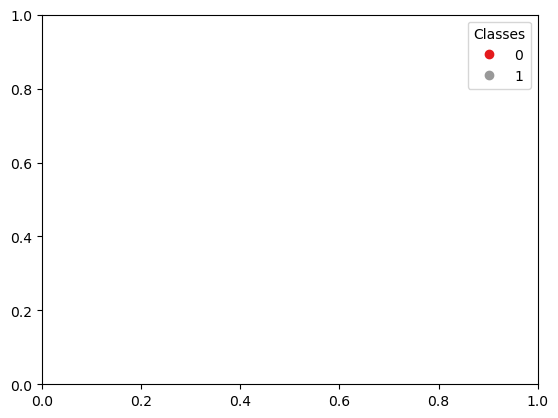

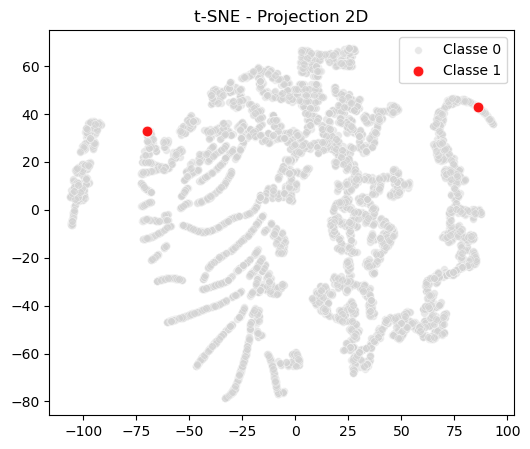

c:\Users\lucna\.conda\envs\IFT599_TP1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


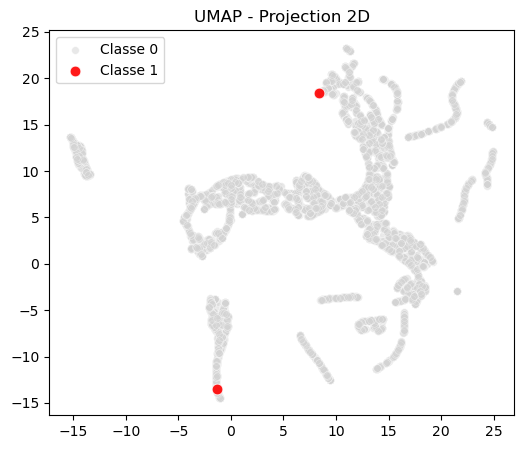

In [28]:
target_col = 'is_fraud'
numeric_cols = ['amount', 'heure']

# On retire la colonne cible
X = df[numeric_cols].values
y = df[target_col].values

# Cela nous donne une matrice de données où
# chaque ligne est une transaction et chaque colonne une caractéristique

# Méthode 1 : PCA
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig = plt.figure(figsize=(12, 5))

# PCA 2D
ax1 = fig.add_subplot(1, 2, 1)
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='Set1', s=40)
ax1.set_title('PCA - Projection 2D')
plt.legend(*scatter1.legend_elements(), title="Classes")
plt.show()

# PCA 3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], np.zeros_like(X_pca[:, 0]), c=y, cmap='Set1', s=40)
ax2.set_title('PCA - Projection 3D')
plt.legend(*scatter2.legend_elements(), title="Classes")
plt.show()

# Méthode 2 : t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_tsne[y==0, 0], y=X_tsne[y==0, 1], color='lightgray', s=30, label='Classe 0', alpha=0.5)
sns.scatterplot(x=X_tsne[y==1, 0], y=X_tsne[y==1, 1], color='red', s=60, label='Classe 1', alpha=0.9)
plt.title('t-SNE - Projection 2D')
plt.show()

# Méthode 3 : UMAP
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
X_umap = reducer.fit_transform(X)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_umap[y==0, 0], y=X_umap[y==0, 1], color='lightgray', s=30, label='Classe 0', alpha=0.5)
sns.scatterplot(x=X_umap[y==1, 0], y=X_umap[y==1, 1], color='red', s=60, label='Classe 1', alpha=0.9)
plt.title('UMAP - Projection 2D')
plt.show()

#### *5.2 Approche univariée (une variable à la fois)*


==== amount ====
T-test: statistic=2.2634, p-value=2.3644e-02
Mann-Whitney: statistic=7001.0000, p-value=9.1768e-01
KS test: statistic=0.4918, p-value=5.3257e-01


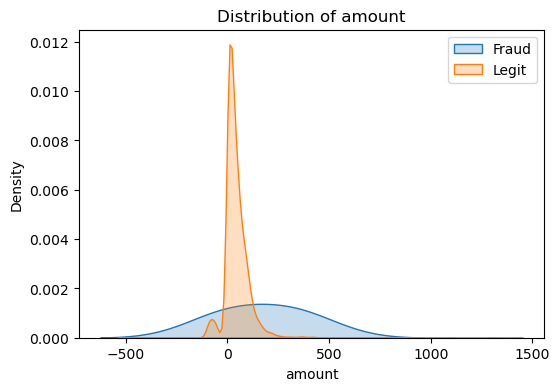


==== heure ====
T-test: statistic=2.4858, p-value=1.2950e-02
Mann-Whitney: statistic=12755.0000, p-value=2.7453e-02
KS test: statistic=0.8873, p-value=2.5492e-02


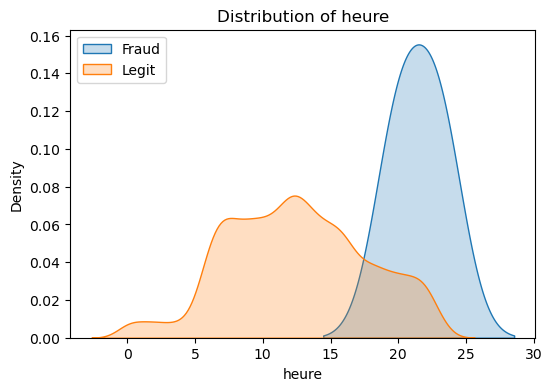

In [29]:
from scipy import stats
for num_cols in numeric_cols:
    fraud = df[df[target_col] == 1][num_cols] # Masking
    legit = df[df[target_col] == 0][num_cols]

    print(f"\n==== {num_cols} ====")

    # t-Test
    t_stat, t_p = stats.ttest_ind(fraud, legit)
    print(f"T-test: statistic={t_stat:.4f}, p-value={t_p:.4e}")

    # Mann-Whitney
    mw_stat, mw_p = stats.mannwhitneyu(fraud, legit, alternative='two-sided')
    print(f"Mann-Whitney: statistic={mw_stat:.4f}, p-value={mw_p:.4e}")

    # Kolmogorov-Smirnov
    ks_stat, ks_p = stats.ks_2samp(fraud, legit)
    print(f"KS test: statistic={ks_stat:.4f}, p-value={ks_p:.4e}")

    # Visualisation
    plt.figure(figsize=(6,4))
    sns.kdeplot(fraud, label="Fraud", fill=True)
    sns.kdeplot(legit, label="Legit", fill=True)
    plt.title(f"Distribution of {num_cols}")
    plt.legend()
    plt.show()

#### *5.3 Approche multivariée (plusieurs variables simultanément)*

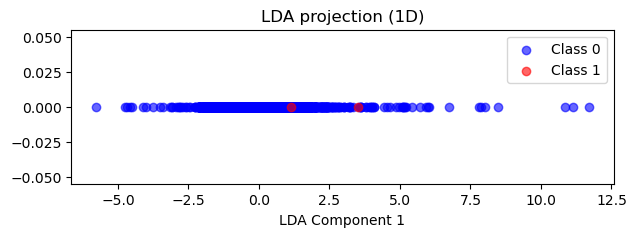

In [30]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.impute import SimpleImputer

# LDA (Linear Discriminant Analysis)
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)

plt.figure(figsize=(7, 2))
plt.scatter(X_lda[y==0], [0]*len(X_lda[y==0]), color='blue', label='Class 0', alpha=0.6)
plt.scatter(X_lda[y==1], [0]*len(X_lda[y==1]), color='red', label='Class 1', alpha=0.6)
plt.title("LDA projection (1D)")
plt.xlabel("LDA Component 1")
plt.legend()
plt.show()

